<a href="https://colab.research.google.com/github/Jenycantik/Kalkulator_/blob/main/Menentukan%20Jumlah%20kebutuhan%20kalori%20harian%20seseorang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tabulate as tabulate
import pandas as pd

In [ ]:
# @title import sqlite dan koneksi
import sqlite3
# koneksi

conn = sqlite3.connect("bmr.db")

In [ ]:
# @title Membuat kursor
# buat cursor
cursor = conn.cursor()

In [ ]:
# @title dipake misal ad eror yang mesti hapus tabel btw td lupa masukin variabel usia
cursor.execute("drop table bmr_record")
conn.commit()

In [ ]:
# tabel data pasien
cursor.execute("""
CREATE TABLE IF NOT EXISTS bmr_record(
    id INTEGER,
    name TEXT NOT NULL,
    jenis_kelamin TEXT NOT NULL,
    berat REAL NOT NULL,
    tinggi REAL NOT NULL,
    usia INTEGER NOT NULL,
    bmr REAL NOT NULL,
    kebutuhan_kalori_per_hari REAL,
    Primary key(id)
    )
""")
print("Tabel berhasil dibuat")
#menyimpan
conn.commit()

NameError: name 'cursor' is not defined

In [ ]:
# @title Perhitungan BMR
# Program Menentukan Jumlah kebutuhan kalori harian seseorang agar tidak melebihi batas wajar serta diharapkan membantu menambah atau mengurangi berat badan
# Untuk laki-laki: (88,4 + 13,4 x berat dalam kilogram) + (4,8 x tinggi dalam sentimeter) - (5,68 x usia dalam tahun)
# Untuk wanita: (447,6 + 9,25 x berat dalam kilogram) + (3,10 x tinggi dalam sentimeter) - (4,33 x usia dalam tahun) source : https://www.alodokter.com/begini-cara-menghitung-kebutuhan-kalori-per-hari#:~:text=Jumlah%20kebutuhan%20kalori%20per%20hari%20didapatkan%20dengan%20menggunakan,ahli%20gizi%20untuk%20menghitung%20BMR%20adalah%20Rumus%20Harris-Benedict.
# Hasil perhitungan BMR kemudian dikalikan dengan angka aktivitas harian rata-rata orang tersebut. Angka ini berkisar antara 1,2–1,9 tergantung dari seberapa tinggi aktivitas harian seseorang.

def hitung_kebutuhan_kalori(jenis_kelamin, berat, tinggi, usia):# fungsi menghitung kebutuhan kalori
    if jenis_kelamin.lower() == "laki-laki":
        return (88.4 + (13.4 * berat) + (4.8 * tinggi) - (5.68 * usia))
    elif jenis_kelamin.lower() == "perempuan":
        return (447.6 + (9.25 * berat) + (3.10 * tinggi) - (4.33 * usia))

def cek_kebutuhan_kalori(kebutuhan_kalori):# fungsi cek kebutuhan kalori per hari
    return kebutuhan_kalori * 1.55  # aktivitas harian rata-rata



In [ ]:
# @title Kode fungsi-fungsi yang masuk ke dalam  menu
def save_bmr_record(name, jenis_kelamin, berat, tinggi, usia, bmr, kebutuhan_kalori_per_hari):
    conn = sqlite3.connect("bmr.db")
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO bmr_record (name, jenis_kelamin, berat, tinggi, usia, bmr, kebutuhan_kalori_per_hari)
    VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (name, jenis_kelamin, berat, tinggi, usia, bmr, kebutuhan_kalori_per_hari))

    conn.commit()
    conn.close()

def update_bmr_record(record_id, name, jenis_kelamin, berat, tinggi, usia):
    kebutuhan_kalori = hitung_kebutuhan_kalori(jenis_kelamin, berat, tinggi, usia)
    kebutuhan_kalori_per_hari = cek_kebutuhan_kalori(kebutuhan_kalori)
    bmr = kebutuhan_kalori  # sama bmr dengan kebutuhan air per hari

    conn = sqlite3.connect("bmr.db")
    cursor = conn.cursor()

    cursor.execute("""
    UPDATE bmr_record
    SET name = ?, jenis_kelamin = ?, berat = ?, tinggi = ?, usia = ?, bmr = ?, kebutuhan_kalori_per_hari = ?
    WHERE id = ?
    """, (name, jenis_kelamin, berat, tinggi, usia, bmr, kebutuhan_kalori_per_hari, record_id))

    conn.commit()
    conn.close()
    print("Data berhasil diperbaharui")

def delete_bmr(record_id):
    conn = sqlite3.connect("bmr.db")
    cursor = conn.cursor()

    cursor.execute("""
    DELETE FROM bmr_record
    WHERE id = ?
    """, (record_id,))

    conn.commit()
    conn.close()
    print("Data berhasil dihapus!")

def display_bmr_records():
    conn = sqlite3.connect("bmr.db")
    cursor = conn.cursor()

    cursor.execute("""SELECT * FROM bmr_record""")
    from tabulate import tabulate
    records = cursor.fetchall()

    # Tampilkan data
    print("\nData BMR yang disimpan:")
    # Definisi header tabel
    headers = ["ID", "Nama", "Jenis Kelamin", "Berat (kg)", "Tinggi (cm)", "Usia (th)", "BMR", "Kalori per Hari"]

    # Cetak tabel menggunakan tabulate
    print(tabulate(records, headers=headers, tablefmt="grid", floatfmt=".2f"))

    conn.close()

In [ ]:
# @title Menu utama
def main():
    while True:
        print("\nMenu:")
        print("1. Tambah Data BMR")
        print("2. Tampilkan Data BMR")
        print("3. Perbaharui Data BMR")
        print("4. Hapus Data BMR")
        print("5. Keluar")

        choice = input("Pilih menu (1/2/3/4/5): ")

        if choice == "1":
            name = input("Masukkan nama: ")
            while True:
                jenis_kelamin = input("Masukkan jenis kelamin (laki-laki/perempuan): ").lower()
                if jenis_kelamin in ['laki-laki', 'perempuan']:
                    break
                else:
                    print("Input salah. Silakan masukkan 'laki-laki' atau 'perempuan'.")

            while True:
                try:
                    berat = float(input("Berat badan (kg): "))
                    break
                except ValueError:
                    print("Input harus berupa angka. Silakan coba lagi.")

            while True:
                try:
                    tinggi = float(input("Tinggi badan (cm): "))
                    break
                except ValueError:
                    print("Input harus berupa angka. Silakan coba lagi.")

            while True:
                try:
                    usia = int(input("Usia (tahun): "))
                    break
                except ValueError:
                    print("Input harus berupa angka. Silakan coba lagi.")

            # Hitung kebutuhan kalori
            kebutuhan_kalori = hitung_kebutuhan_kalori(jenis_kelamin, berat, tinggi, usia)
            kebutuhan_kalori_per_hari = cek_kebutuhan_kalori(kebutuhan_kalori)

            # Simpan data BMR
            save_bmr_record(name, jenis_kelamin, berat, tinggi, usia, kebutuhan_kalori, kebutuhan_kalori_per_hari)
            print("Data BMR berhasil disimpan!")

        elif choice == "2":
            display_bmr_records()

        elif choice == "3":
          display_bmr_records()
          while True:
              try:
                  record_id = int(input("Masukkan ID data yang ingin diperbaharui: "))
                  break
              except ValueError:
                  print("Input harus berupa angka. Silakan coba lagi.")

          name = input("Masukkan nama: ")
          while True:
              jenis_kelamin = input("Masukkan jenis kelamin (laki-laki/perempuan): ").lower()
              if jenis_kelamin in ['laki-laki', 'perempuan']:
                  break
              else:
                  print("Input salah. Silakan masukkan 'laki-laki' atau 'perempuan'.")

          while True:
              try:
                  berat = float(input("Berat badan (kg): "))
                  break
              except ValueError:
                  print("Input harus berupa angka. Silakan coba lagi.")

          while True:
              try:
                  tinggi = float(input("Tinggi badan (cm): "))
                  break
              except ValueError:
                  print("Input harus berupa angka. Silakan coba lagi.")

          while True:
              try:
                  usia = int(input("Usia (tahun): "))
                  break
              except ValueError:
                  print("Input harus berupa angka. Silakan coba lagi.")

            # Perbarui data BMR
          update_bmr_record(record_id, name, jenis_kelamin, berat, tinggi, usia)
          print("Data BMR berhasil diperbaharui!")

        elif choice == "4":
          display_bmr_records()
          record_id = int(input("Masukkan ID data yang ingin dihapus: "))
          delete_bmr(record_id)
          print("Data BMR berhasil dihapus!")

        elif choice == "5":
            print("Terima kasih! Program selesai.")
            break

        else:
            print("Pilihan tidak valid. Silakan pilih menu yang tersedia.")

# Pastikan untuk memanggil fungsi main
main()


Menu:
1. Tambah Data BMR
2. Tampilkan Data BMR
3. Perbaharui Data BMR
4. Hapus Data BMR
5. Keluar
Pilih menu (1/2/3/4/5): 5
Terima kasih! Program selesai.


In [ ]:
aero = pd.read_csv("/content/data_keren.csv")

aero["Kebutuhan_Kalori_Harian"] = aero.apply(
    lambda row: hitung_kebutuhan_kalori(
        row["Jenis_Kelamin"], row["Berat"], row["Tinggi"], row["Usia"]
    ),
    axis=1,
)
print(aero)

     Nama Jenis_Kelamin  Berat  Tinggi  Usia        Asal        Pekerjaan
0    Andi     Laki-laki     70     175    25     Bandung          Pelajar
1    Budi     Laki-laki     80     180    30   Pontianak              PNS
2   Citra     Perempuan     55     160    22      Manado         Desainer
3    Dewi     Perempuan     60     165    28   Pekanbaru        Mahasiswa
4     Eka     Laki-laki     75     172    27    Semarang  Karyawan Swasta
5    Fani     Perempuan     50     158    23    Makassar           Petani
6    Gita     Perempuan     58     162    24    Semarang  Karyawan Swasta
7    Hadi     Laki-laki     85     185    35  Balikpapan          Perawat
8     Ira     Perempuan     52     159    21      Manado            Sopir
9    Joko     Laki-laki     90     190    32      Manado          Seniman
10   Kiki     Laki-laki     68     178    26   Pontianak          Arsitek
11   Lina     Perempuan     53     157    20      Manado  Karyawan Swasta
12   Mila     Perempuan     57     161

In [ ]:
aero = pd.read_csv("/content/data_keren.csv")

aero["Kebutuhan_Kalori_Harian"] = aero.apply(
    lambda row: hitung_kebutuhan_kalori(
        row["Jenis_Kelamin"], row["Berat"], row["Tinggi"], row["Usia"]
    ),
    axis=1,
)
print(aero)

     Nama Jenis_Kelamin  Berat  Tinggi  Usia        Asal        Pekerjaan  \
0    Andi     Laki-laki     70     175    25     Bandung          Pelajar   
1    Budi     Laki-laki     80     180    30   Pontianak              PNS   
2   Citra     Perempuan     55     160    22      Manado         Desainer   
3    Dewi     Perempuan     60     165    28   Pekanbaru        Mahasiswa   
4     Eka     Laki-laki     75     172    27    Semarang  Karyawan Swasta   
5    Fani     Perempuan     50     158    23    Makassar           Petani   
6    Gita     Perempuan     58     162    24    Semarang  Karyawan Swasta   
7    Hadi     Laki-laki     85     185    35  Balikpapan          Perawat   
8     Ira     Perempuan     52     159    21      Manado            Sopir   
9    Joko     Laki-laki     90     190    32      Manado          Seniman   
10   Kiki     Laki-laki     68     178    26   Pontianak          Arsitek   
11   Lina     Perempuan     53     157    20      Manado  Karyawan Swasta   

In [ ]:
# @title versi estetik
from tabulate import tabulate

aero["Kebutuhan_Kalori_Harian"] = aero.apply(
    lambda row: hitung_kebutuhan_kalori(
        row["Jenis_Kelamin"], row["Berat"], row["Tinggi"], row["Usia"]
    ),
    axis=1,
)
print(tabulate(aero, headers='keys', tablefmt='grid', floatfmt=".2f"))

+----+--------+-----------------+---------+----------+--------+------------+-----------------+---------------------------+
|    | Nama   | Jenis_Kelamin   |   Berat |   Tinggi |   Usia | Asal       | Pekerjaan       |   Kebutuhan_Kalori_Harian |
+====+========+=================+=========+==========+========+============+=================+===========================+
|  0 | Andi   | Laki-laki       |      70 |      175 |     25 | Bandung    | Pelajar         |                   1724.40 |
+----+--------+-----------------+---------+----------+--------+------------+-----------------+---------------------------+
|  1 | Budi   | Laki-laki       |      80 |      180 |     30 | Pontianak  | PNS             |                   1854.00 |
+----+--------+-----------------+---------+----------+--------+------------+-----------------+---------------------------+
|  2 | Citra  | Perempuan       |      55 |      160 |     22 | Manado     | Desainer        |                   1357.09 |
+----+--------+-

In [ ]:
# Menghapus beberapa kolom
aero = aero.drop(['Asal', 'Pekerjaan'], axis=1, errors='ignore')

print("\nDataFrame Setelah Menghapus Kolom 'Asal' dan 'Pekerjaan':")
print(tabulate(aero, headers='keys', tablefmt='grid', floatfmt=".2f"))


DataFrame Setelah Menghapus Kolom 'Asal' dan 'Pekerjaan':
+----+--------+-----------------+---------+----------+--------+---------------------------+
|    | Nama   | Jenis_Kelamin   |   Berat |   Tinggi |   Usia |   Kebutuhan_Kalori_Harian |
+====+========+=================+=========+==========+========+===========================+
|  0 | Andi   | Laki-laki       |      70 |      175 |     25 |                   1724.40 |
+----+--------+-----------------+---------+----------+--------+---------------------------+
|  1 | Budi   | Laki-laki       |      80 |      180 |     30 |                   1854.00 |
+----+--------+-----------------+---------+----------+--------+---------------------------+
|  2 | Citra  | Perempuan       |      55 |      160 |     22 |                   1357.09 |
+----+--------+-----------------+---------+----------+--------+---------------------------+
|  3 | Dewi   | Perempuan       |      60 |      165 |     28 |                   1392.86 |
+----+--------+------

In [ ]:
# Menambahkan kolom 'kesimpulan' berdasarkan kategori kebutuhan kalori harian
# kebutuhan kalori harian rata rata orang itu 2100 tapi saya genapkan supaya keren karena sebenarnya 1,55 tu aktifitas fisik pasti aktivitas rata rata orang lebih besar
aero['kesimpulan'] = pd.cut(
    aero['Kebutuhan_Kalori_Harian'],
    bins=[0, 2000.00, float('inf')],
    labels=['<2000', '>2000']
)

# Menampilkan beberapa baris dengan kolom baru
print(aero[['Nama', 'Kebutuhan_Kalori_Harian', 'kesimpulan']].head(10))

    Nama  Kebutuhan_Kalori_Harian kesimpulan
0   Andi                  1724.40      <2000
1   Budi                  1854.00      <2000
2  Citra                  1357.09      <2000
3   Dewi                  1392.86      <2000
4    Eka                  1765.64      <2000
5   Fani                  1300.31      <2000
6   Gita                  1382.38      <2000
7   Hadi                  1916.60      <2000
8    Ira                  1330.57      <2000
9   Joko                  2024.64      >2000


<ipython-input-115-4b69572c6656>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='kesimpulan', data=aero, palette='tab10')


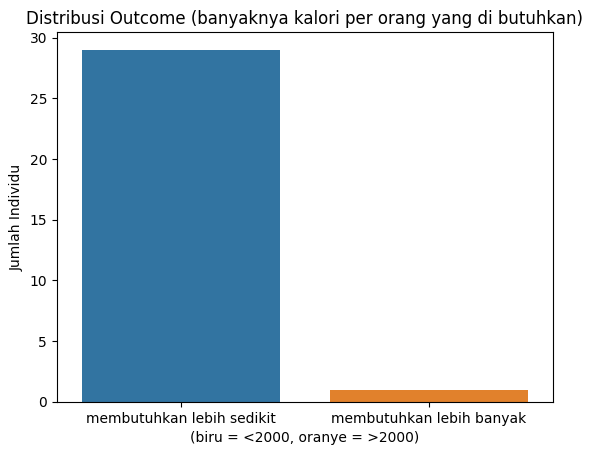

kesimpulan
<2000    29
>2000     1
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='kesimpulan', data=aero, palette='tab10')
plt.title('Distribusi Outcome (banyaknya kalori per orang yang di butuhkan)')
plt.xlabel('(biru = <2000, oranye = >2000)')
plt.ylabel('Jumlah Individu')
plt.xticks([0, 1], ['membutuhkan lebih sedikit', 'membutuhkan lebih banyak'])
plt.show()

# Menampilkan
print(aero['kesimpulan'].value_counts())

In [ ]:
import numpy as np
rata_rata = np.mean(aero['Kebutuhan_Kalori_Harian'])
print(f"Rata-rata Kebutuhan Kalori Per Hari dari 30 orang tersebut : {rata_rata:.2f} cal")

Rata-rata Kebutuhan Kalori Per Hari dari 30 orang tersebut : 1567.00 cal


In [ ]:
# @title eksport data
aero.to_excel('data_kalori.xlsx', index=False)  # index=False untuk tidak menyertakan index
print("Data telah diekspor ke data_kalori.xlsx.")

Data telah diekspor ke data_kalori.xlsx.
